In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis
import deepssfp.dataloader

In [2]:
path = 'D:/MRI/2024_Krithika_KneeStudy'
filters = ['HV1_lk_r1', 'HV2_lk_r1', 'HV3_lk_r1', 'HV4_lk_r1', 'HV5_lk_r1']
M = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters)
print(M.shape)

new_shape = (M.shape[0] * M.shape[1],) + M.shape[2:]
M = M.reshape(new_shape)
print(M.shape)

memory_size = M.nbytes
print(f"Memory size: {memory_size / 1000000000} GB")

from skimage.filters import threshold_li
def create_segmentation_mask(M):
    # Create mask of phantom
    _ = np.sqrt(np.sum(np.abs(M)**2, axis=3))
    _ = abs(_)
    thresh = threshold_li(_)
    mask = np.abs(_) > thresh
    seg = mask * 1
    return seg

seg = create_segmentation_mask(M)
print(f"Segmentation shape: {seg.shape}")
print(f"Segmentation values: {np.unique(seg)}")

dataset = { 'M': M, 'seg': seg }

100%|██████████| 4/4 [00:11<00:00,  2.84s/it]


(5, 80, 416, 416, 4)
(400, 416, 416, 4)
Memory size: 2.2151168 GB
Segmentation shape: (400, 416, 416)
Segmentation values: [0 1]


In [3]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="knee_study"


===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/knee_study_syntheticbanding
Dataset path: D:/DeepSSFP/knee_study_dataset.npy
Data shape: (400, 416, 416, 4)
Using same scaler for SyntheticBanding mode
Training data shape: (320, 416, 416, 4), (320, 416, 416, 4)
Input scaler stats: mean=0.1445, std=25.5165
Output scaler stats: mean=0.1445, std=25.5165
Selected indices: [50 22 63]
Figure size: (8, 6)


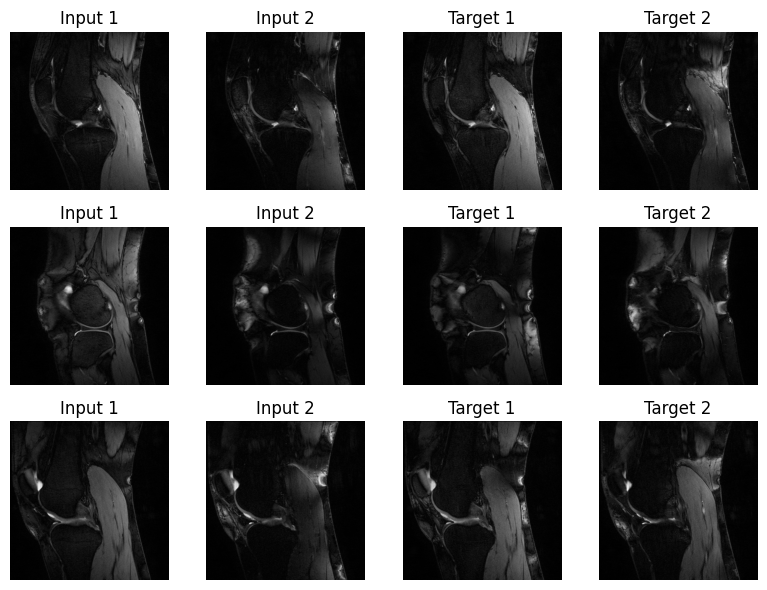

2025-04-05 23:26:42,973 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/knee_study_syntheticbanding
2025-04-05 23:26:42,986 - DeepSSFP - INFO - Training DataSet: (320, 416, 416, 4) | (320, 416, 416, 4)
2025-04-05 23:26:42,986 - DeepSSFP - INFO - Test DataSet: (80, 416, 416, 4) | (80, 416, 416, 4)



Training model...


2025-04-05 23:26:44,033 - DeepSSFP - INFO - Creating new model with dimensions: 416x416x4→4
2025-04-05 23:26:44,843 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 416, 416, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 416, 416, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 416, 416, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 416, 416, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-04-06 00:37:02,416 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/knee_study_syntheticbanding.keras


3/3 [==============================] - 4s 129ms/step - loss: 0.0890 - mean_absolute_error: 0.1845


2025-04-06 00:37:07,697 - DeepSSFP - INFO - Training Complete. Loss: 0.0890, MAE: 0.1845
2025-04-06 00:37:07,698 - DeepSSFP - INFO - Time Elapsed: 4222.84 seconds
2025-04-06 00:37:09,272 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/knee_study_syntheticbanding_training_history.png


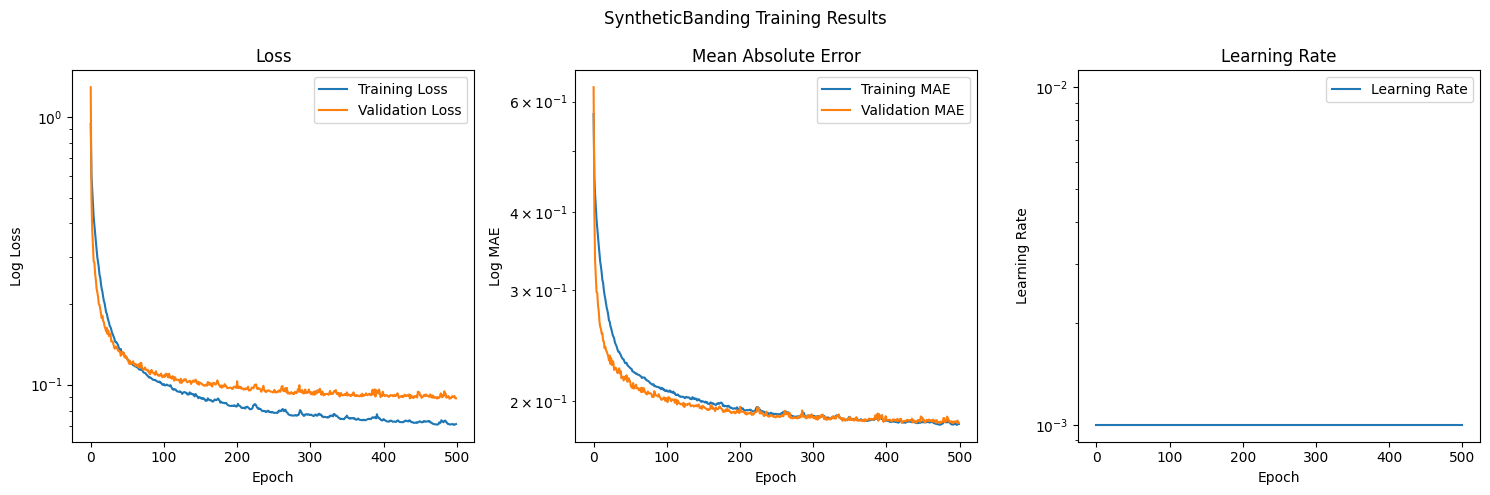

Using same scaler for SyntheticBanding mode


2025-04-06 00:37:41,213 - DeepSSFP - INFO - Making predictions on data with shape (80, 416, 416, 4)
2025-04-06 00:37:42,706 - DeepSSFP - INFO - Predictions complete. Output shape: (80, 416, 416, 4)


Selected indices: [34 72]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/knee_study_syntheticbanding_prediction_results.png


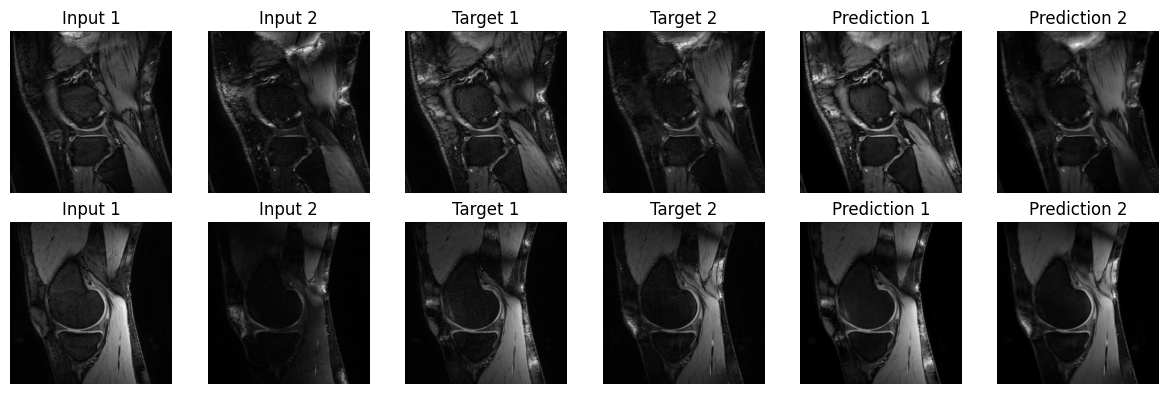

real/imag pairs -> complex
real/imag pairs -> complex
Target shape: (80, 416, 416), Prediction shape: (80, 416, 416)


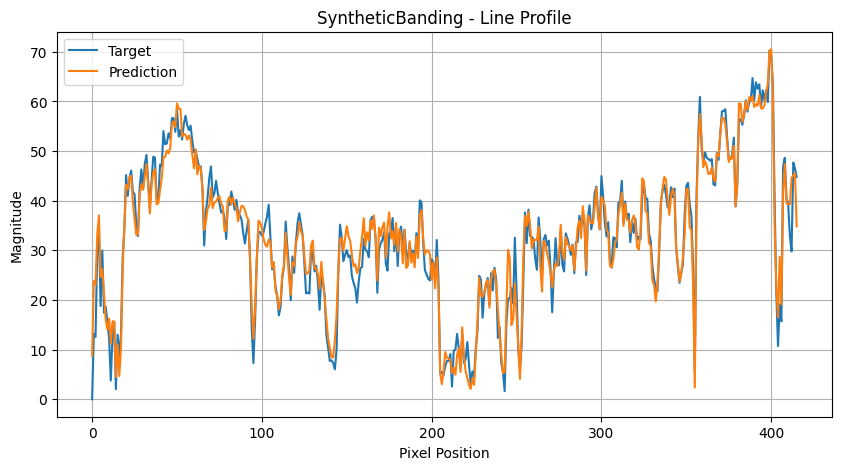


Evaluating band reduction...
Target shape: (80, 416, 416)
Prediction shape: (80, 416, 416)
Segmentation shape: (80, 416, 416)
Unique segmentation IDs: [0 1]
IDs to plot: [1]
Training history plot saved to D:/DeepSSFP/knee_study_syntheticbanding_band_metrics_scatter


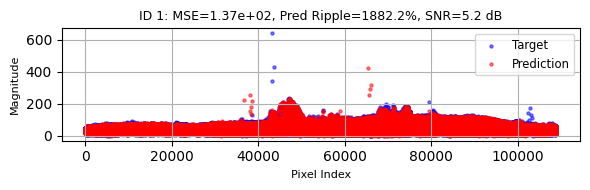

Training history plot saved to D:/DeepSSFP/knee_study_syntheticbanding_band_metrics


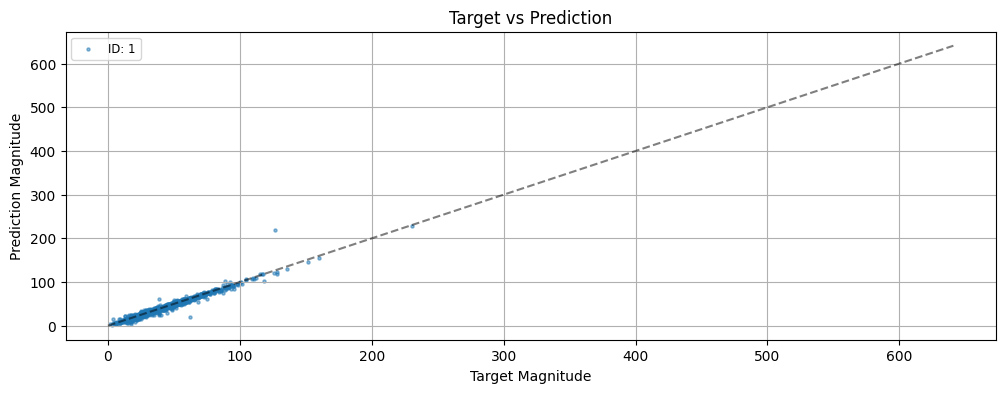


Metrics by Segment ID (averaged across all samples):
ID 1: MSE=1.37e+02, MAE=3.05e+00, Pred Min=0.2158, Pred Max=579.3600, Pred Ripple=1882.19%, Pred SNR=5.2 dB, Target Min=0.2079, Target Max=958.7802, Target Ripple=2882.51%, Target SNR=5.6 dB, Samples=80, Pixels=108917

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 57.764554
  MAE: 1.915266
  PSNR: 31.746720
  SSIM: 0.821457
  NRMSE: 0.201242

SEGMENT_0:
  MSE: 15.342480
  MAE: 1.266057
  PSNR: 23.342495
  SSIM: nan
  NRMSE: 0.342320

SEGMENT_1:
  MSE: 137.466366
  MAE: 3.046984
  PSNR: 27.371111
  SSIM: nan
  NRMSE: 0.193130
Metrics saved to D:/DeepSSFP/knee_study_syntheticbanding_all_metrics.npy


In [4]:
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    custom_dataset=dataset,
    save_dataset=True,
)